# Анализ на EEG Сигнали (Exploratory Data Analysis)

Този ноутбук представя стъпките за проучвателен анализ на EEG данни, включително зареждане на данни, описателни статистики, визуализация във времевата и честотната област, и откриване на аномалии.


## 1. Зареждане на библиотеки и настройки

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from sklearn.preprocessing import StandardScaler

# Добавяне на пътя към проекта за импортиране на модули
repo_root = os.path.dirname(os.getcwd()) # Assuming notebook is in notebooks/ dir
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.data_processing.loader import load_bonn_data

# Настройки за визуализация
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)


## 2. Зареждане на данните

Използваме `load_bonn_data` за зареждане на суровите EEG записи. Данните се състоят от 500 записа (по 100 от всеки от 5-те подмножества), обединени в 3 класа:
*   **0 (Healthy):** Z, O
*   **1 (Inter-ictal):** N, F
*   **2 (Seizure):** S


In [2]:
print("Loading data via load_bonn_data...")
data_path = os.path.join(repo_root, 'data', 'raw')
X_np, y_np = load_bonn_data(data_path)

# Преобразуване в DataFrame за удобство (редове = записи, колони = времеви точки)
X = pd.DataFrame(X_np)
y = pd.Series(y_np, name="y")

print(f"Data loaded: X shape={X.shape}, y shape={y.shape}")


Loading data via load_bonn_data...
Loading 100 files from Z mapped to Class 0...
Loading 100 files from O mapped to Class 0...
Loading 100 files from N mapped to Class 1...
Loading 100 files from F mapped to Class 1...
Loading 100 files from S mapped to Class 2...
Data loaded: X shape=(500, 4097), y shape=(500,)


## 3. Описателни статистики

Изчисляваме основни статистически показатели (средно, стандартно отклонение, минимум, максимум) за всеки запис. Това ни дава представа за обхвата на амплитудите.


In [3]:
# Транспониране, за да получим статистики за всеки запис (ред)
stats = X.T.describe().T[["mean", "std", "min", "max"]]
print("Descriptive statistics (first 5 samples):")
print(stats.head())


Descriptive statistics (first 5 samples):
        mean        std    min    max
0 -75.103734  23.117265 -152.0    3.0
1  -3.992433  47.078062 -181.0  162.0
2 -27.369539  43.705649 -190.0  122.0
3 -13.600195  38.421234 -163.0  136.0
4 -17.999268  44.916440 -188.0  152.0


## 4. Визуализация на EEG сигнал (Времеви ред)

Визуализираме един примерен "суров" EEG сигнал, за да видим неговата структура във времето.


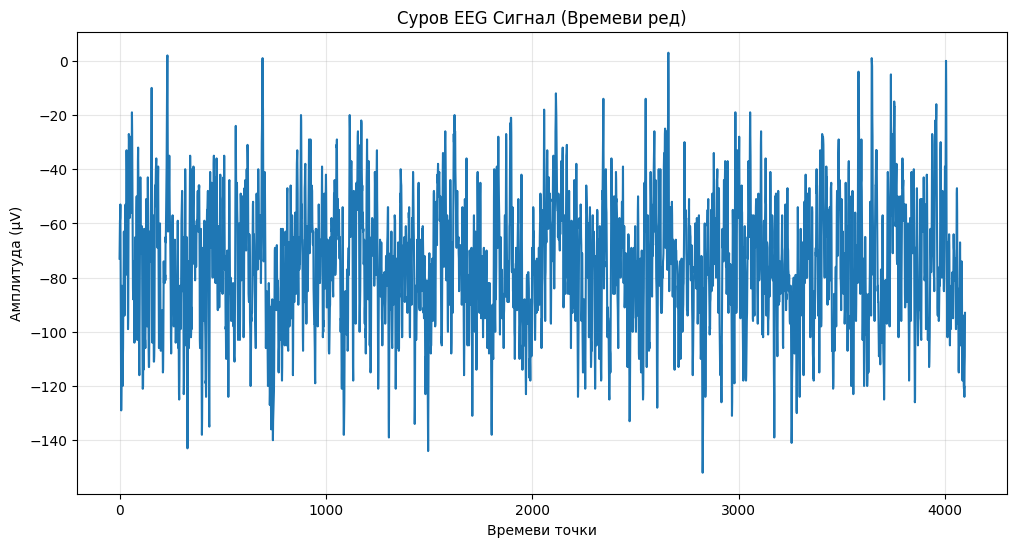

In [4]:
sample_idx = 0
signal = X.iloc[sample_idx].values

plt.figure()
plt.plot(signal)
plt.title("Суров EEG Сигнал (Времеви ред)")
plt.xlabel("Времеви точки")
plt.ylabel("Амплитуда (µV)")
plt.grid(True, alpha=0.3)
plt.show()


## 5. Нискочестотна филтрация (Low-pass filter)

Прилагаме нискочестотен филтър (Butterworth, Low-pass) с гранична честота 40 Hz, за да премахнем високочестотния шум (напр. от електрическата мрежа или мускулни съкращения).


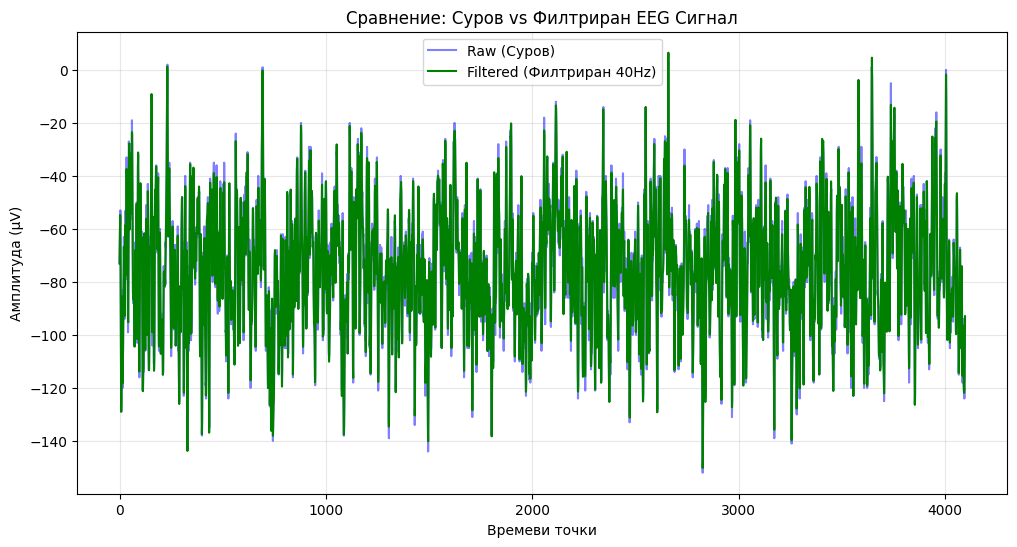

In [5]:
fs = 173.61  # Честота на дискретизация

def lowpass_filter(signal, fs=173.61, cutoff=40, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

filtered_signal = lowpass_filter(signal, fs=fs)

plt.figure()
plt.plot(signal, label="Raw (Суров)", alpha=0.5, color='blue')
plt.plot(filtered_signal, label="Filtered (Филтриран 40Hz)", color='green', linewidth=1.5)
plt.legend()
plt.title("Сравнение: Суров vs Филтриран EEG Сигнал")
plt.xlabel("Времеви точки")
plt.ylabel("Амплитуда (µV)")
plt.grid(True, alpha=0.3)
plt.show()


## 6. Откриване на аномалии (Boxplot)

Boxplot диаграмата помага за идентифициране на екстремни амплитуди (outliers) и разпределението на сигнала.


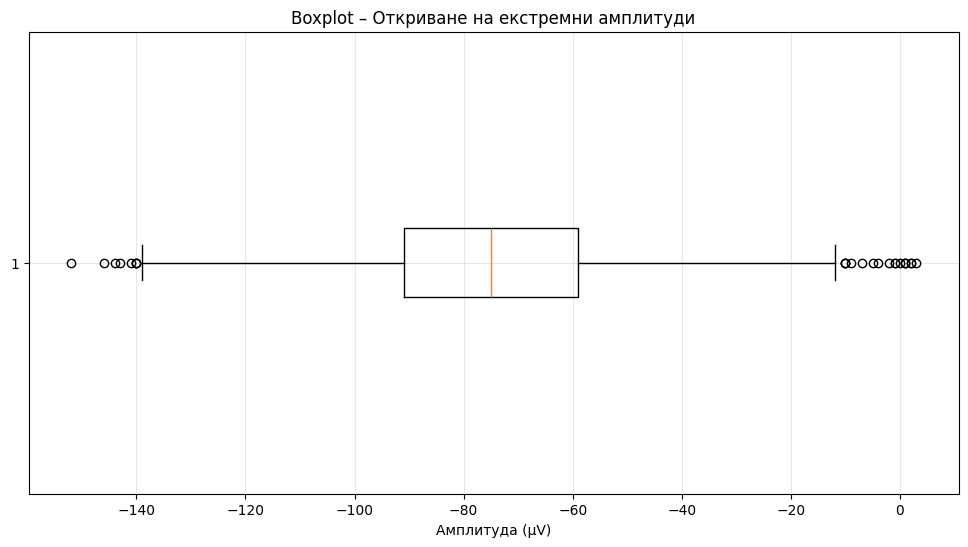

In [6]:
plt.figure()
plt.boxplot(signal, vert=False)
plt.title("Boxplot – Откриване на екстремни амплитуди")
plt.xlabel("Амплитуда (µV)")
plt.grid(True, alpha=0.3)
plt.show()


## 7. Анализ на резки промени (Time-series)

Изчисляваме първата разлика (First-order Difference) на сигнала, за да подчертаем резките промени в амплитудата.


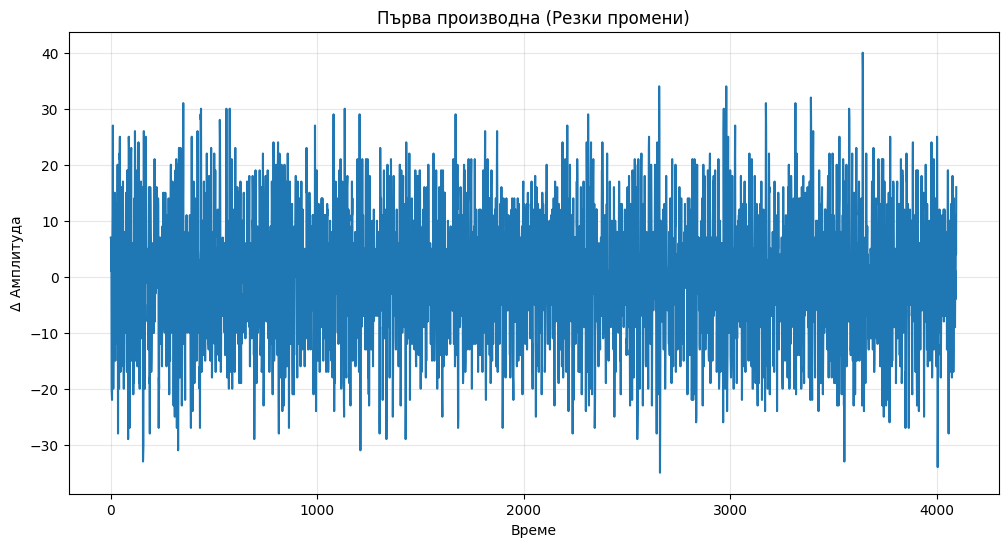

In [7]:
plt.figure()
plt.plot(np.diff(signal))
plt.title("Първа производна (Резки промени)")
plt.xlabel("Време")
plt.ylabel("Δ Амплитуда")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Честотен анализ (Power Spectral Density)

Изчисляваме и визуализираме Спектралната плътност на мощността (PSD) чрез метода на Welch. Това показва кои честоти преобладават в сигнала.


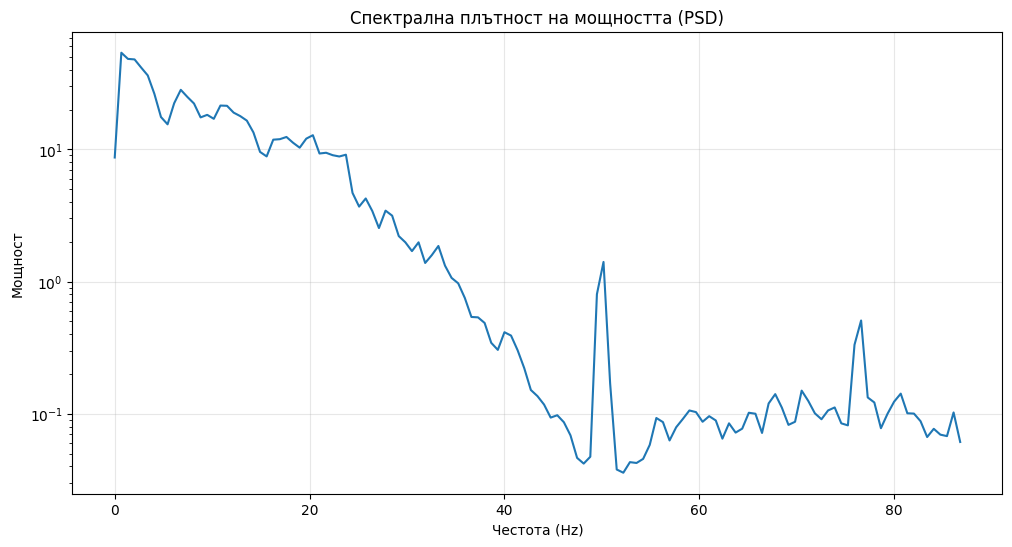

In [8]:
freqs, psd = welch(signal, fs)

plt.figure()
plt.semilogy(freqs, psd)
plt.title("Спектрална плътност на мощността (PSD)")
plt.xlabel("Честота (Hz)")
plt.ylabel("Мощност")
plt.grid(True, alpha=0.3)
plt.show()


## 9. Корелационен анализ (Heatmap)

Изследваме корелациите между различни времеви точки на сигнала (за подмножество от данните). Това показва зависимостите в сигнала.


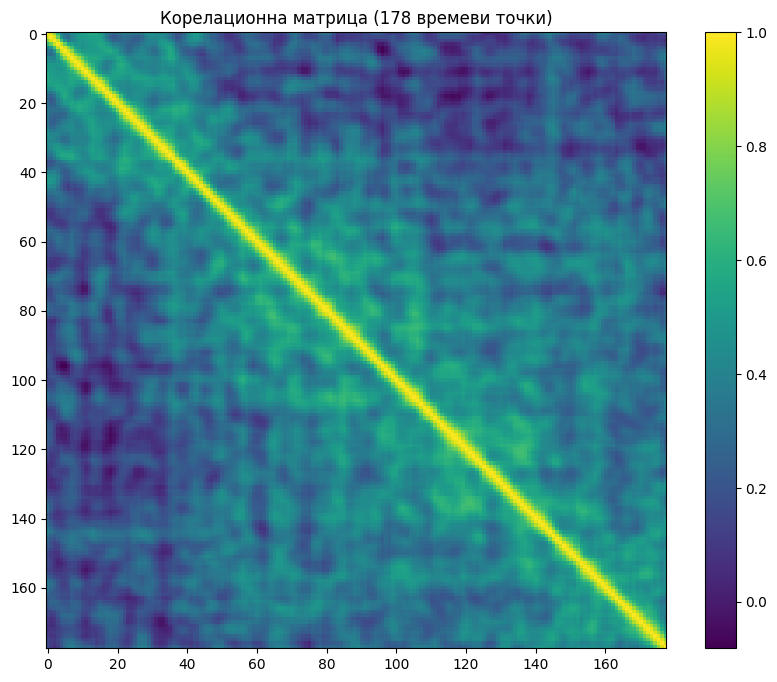

In [9]:
# Използваме подмножество за по-бърза визуализация (първите 200 записа и първите 20 точки)
# Или може да корелираме целите записи ако транспонираме? 
# Обикновено features се корелират. Тук X са raw points. 
# Ще покажем корелация между първите 50 времеви точки.
subset = X.iloc[:100, :178]  
corr = subset.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Корелационна матрица (178 времеви точки)")
plt.show()


## 10. Z-score Стандартизация

Демонстрираме ефекта на Z-score стандартизацията, която центрира данните около 0 и ги мащабира до единична вариация.


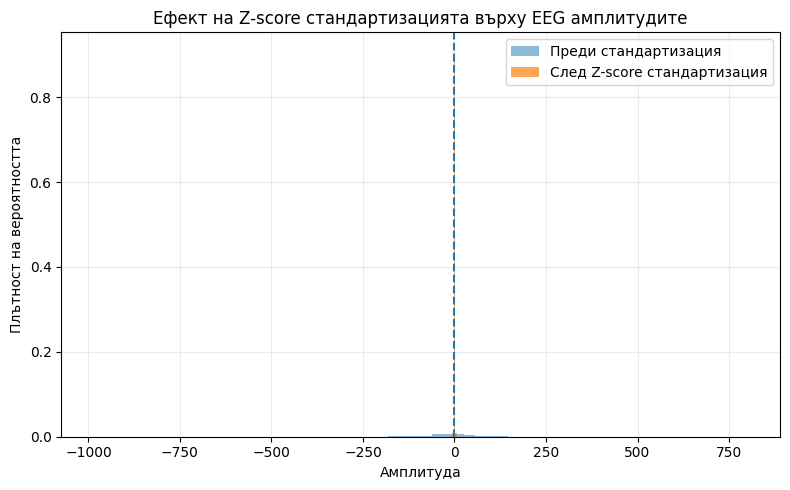

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Данни за сравнение: преди и след
raw_feature = X.iloc[:, 0].values
scaled_feature = X_scaled[:, 0]

plt.figure(figsize=(8, 5))

plt.hist(
    raw_feature,
    bins=60,
    alpha=0.5,
    density=True,
    label="Преди стандартизация",
)

plt.hist(
    scaled_feature,
    bins=60,
    alpha=0.7,
    density=True,
    label="След Z-score стандартизация",
)

plt.axvline(0, linestyle="--", linewidth=1.5)

plt.title("Ефект на Z-score стандартизацията върху EEG амплитудите")
plt.xlabel("Амплитуда")
plt.ylabel("Плътност на вероятността")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()
